#**MACHINE FAILURE PREDICTION**

In [ ]:
!pip install keras_tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 2.5 MB/s eta 0:00:00


In [ ]:
import gdown
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px
import joblib
from tqdm import tqdm

# error
import warnings
warnings.filterwarnings('ignore')

# preprocessing
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Keras
import keras_tuner as kt
from tensorflow import keras
import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping

# ML
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

In [ ]:
gdown.download(id='1l9uAQvJJ_UE07Euked7CVs4WGSkSZIC9', output='machine_failure.csv', quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1l9uAQvJJ_UE07Euked7CVs4WGSkSZIC9
To: /content/machine_failure.csv
100%|██████████| 22.5k/22.5k [00:00<00:00, 37.6MB/s]


'machine_failure.csv'

# 1. Data Understanding

In [ ]:
df = pd.read_csv('machine_failure.csv')
df.head()

,footfall,tempMode,AQ,USS,CS,VOC,RP,IP,Temperature,fail
0,0,7,7,1,6,6,36,3,1,1
1,190,1,3,3,5,1,20,4,1,0
2,31,7,2,2,6,1,24,6,1,0
3,83,4,3,4,5,1,28,6,1,0
4,640,7,5,6,4,0,68,6,1,0


- `footfall`: Jumlah orang atau objek yang melewati mesin.
- `tempMode`: Mode atau pengaturan suhu pada mesin.
- `AQ`: Indeks kualitas udara di sekitar mesin.
- `USS`: Data sensor ultrasonik yang menunjukkan pengukuran jarak atau kedekatan.
- `CS`: Pembacaan sensor arus listrik yang menunjukkan penggunaan arus listrik oleh mesin.
- `VOC`: Tingkat senyawa organik volatil yang terdeteksi di sekitar mesin.
- `RP`: Posisi rotasi atau RPM (putaran per menit) dari bagian-bagian mesin.
- `IP`: Tekanan masuk ke mesin.
- `Temperature`: Suhu operasi mesin.
- `fail`: Indikator biner kegagalan mesin (1 untuk gagal, 0 untuk tidak gagal).

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 944 entries, 0 to 943
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   footfall     944 non-null    int64
 1   tempMode     944 non-null    int64
 2   AQ           944 non-null    int64
 3   USS          944 non-null    int64
 4   CS           944 non-null    int64
 5   VOC          944 non-null    int64
 6   RP           944 non-null    int64
 7   IP           944 non-null    int64
 8   Temperature  944 non-null    int64
 9   fail         944 non-null    int64
dtypes: int64(10)
memory usage: 73.9 KB


In [ ]:
df.shape

(944, 10)

In [ ]:
df.describe()

,footfall,tempMode,AQ,USS,CS,VOC,RP,IP,Temperature,fail
count,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000
mean,306.381356,3.727754,4.325212,2.939619,5.394068,2.842161,47.043432,4.565678,16.331568,0.416314
std,1082.606745,2.677235,1.438436,1.383725,1.269349,2.273337,16.423130,1.599287,5.974781,0.493208
min,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,19.000000,1.000000,1.000000,0.000000
25%,1.000000,1.000000,3.000000,2.000000,5.000000,1.000000,34.000000,3.000000,14.000000,0.000000
50%,22.000000,3.000000,4.000000,3.000000,6.000000,2.000000,44.000000,4.000000,17.000000,0.000000
75%,110.000000,7.000000,6.000000,4.000000,6.000000,5.000000,58.000000,6.000000,21.000000,1.000000
max,7300.000000,7.000000,7.000000,7.000000,7.000000,6.000000,91.000000,7.000000,24.000000,1.000000


# 2. Data Cleaning

## 2.1. Checking & Handle Missing Value

In [ ]:
df.isnull().sum()

,0
footfall,0
tempMode,0
AQ,0
USS,0
CS,0
VOC,0
RP,0
IP,0
Temperature,0
fail,0


## 2.2. Checking & Handle Duplikasi Data

In [ ]:
df.duplicated().sum()

np.int64(1)

In [ ]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

## 2.3. Checking & Handle Outlier Data

<Axes: >

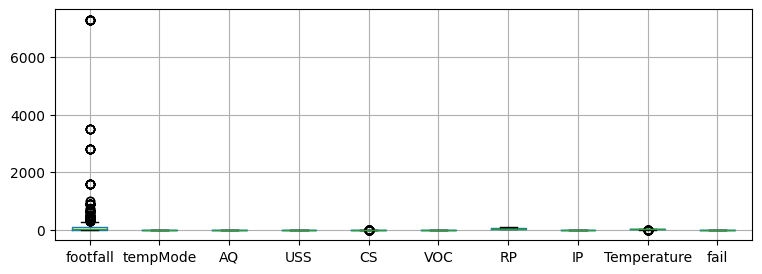

In [ ]:
df.boxplot(figsize=(9,3))

In [ ]:
from scipy.stats import zscore
import numpy as np

z_scores = np.abs(zscore(df.select_dtypes(include=[np.number])))
df_clean = df[(z_scores < 3).all(axis=1)]

df_clean.shape

(912, 10)

## 2.1. Checking & Handle Imbalance Data

fail
0    550
1    393
Name: count, dtype: int64


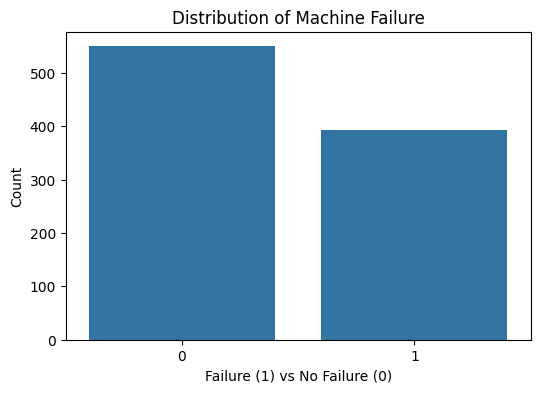

In [ ]:
# check imbalance data
print(df['fail'].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x='fail', data=df)
plt.title('Distribution of Machine Failure')
plt.xlabel('Failure (1) vs No Failure (0)')
plt.ylabel('Count')
plt.show()

Setelah SMOTE ((1100, 9), (1100,))


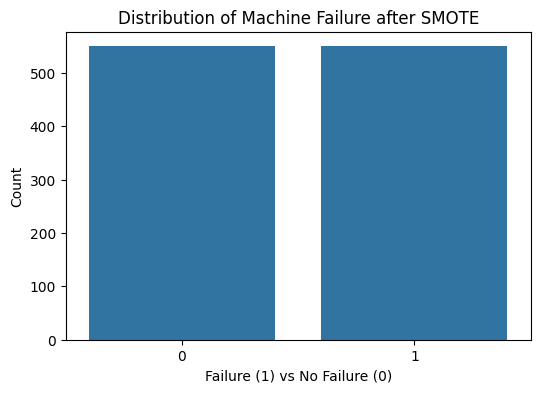

In [ ]:
X = df.drop('fail', axis=1)
y = df['fail']

# Apply SMOTE to oversample the minority class (failure = 1)
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print(f"Setelah SMOTE {X_resampled.shape, y_resampled.shape}")

plt.figure(figsize=(6, 4))
sns.countplot(x=y_resampled)
plt.title('Distribution of Machine Failure after SMOTE')
plt.xlabel('Failure (1) vs No Failure (0)')
plt.ylabel('Count')
plt.show()

# 3. EDA

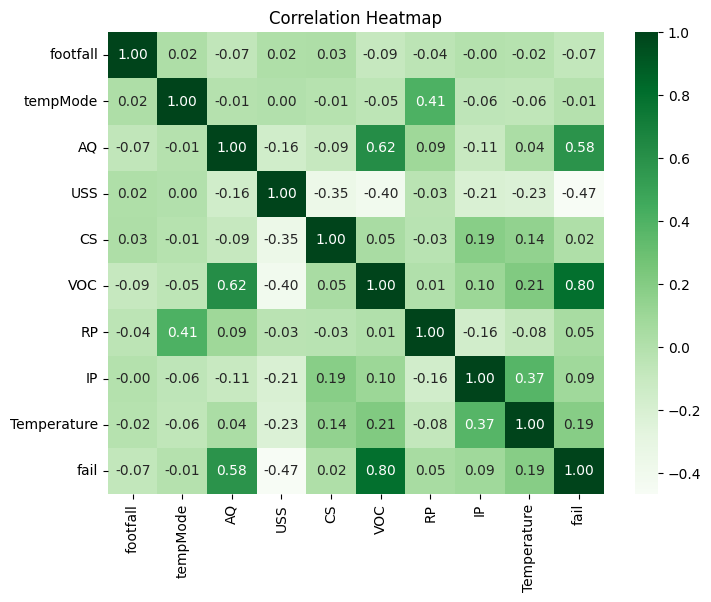

In [ ]:
corr_matrix = df.corr(method='pearson')
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='Greens', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

- **AQ dan fail** memiliki korelasi positif sedang sebesar **0,58**, artinya semakin tinggi kualitas udara (AQ), kemungkinan kegagalan mesin (fail) cenderung meningkat.
- **VOC dan fail** memiliki korelasi positif kuat sebesar **0,80**, menunjukkan bahwa tingkat senyawa organik volatil yang tinggi sangat terkait dengan kegagalan mesin.
- **USS dan fail** memiliki korelasi negatif sebesar **-0,47**, artinya semakin tinggi nilai sensor ultrasonik (USS), kemungkinan kegagalan mesin cenderung menurun.
- **temp_mode dan RP** memiliki korelasi positif sebesar **0,42**, mengindikasikan hubungan sedang antara mode suhu dan posisi rotasi mesin.
- **AQ dan VOC** memiliki korelasi positif sebesar **0,62**, menunjukkan bahwa kualitas udara dan tingkat VOC saling terkait.
- **USS dan VOC** memiliki korelasi negatif sebesar **-0,40**, menandakan ketika sensor ultrasonik tinggi, tingkat VOC cenderung rendah.
- **USS dan CS** berkorelasi negatif sebesar **-0,35**, menunjukkan hubungan terbalik antara sensor ultrasonik dan arus listrik.
- **IP dan Temperature** berkorelasi positif sebesar **0,37**, menandakan tekanan masuk dan suhu operasi mesin saling berhubungan.
- **USS dan IP** berkorelasi negatif kecil sebesar **-0,21,** dan USS dengan Temperature berkorelasi negatif kecil sebesar **-0,23**, menunjukkan hubungan lemah terbalik.

# 4. Data Modeling

## 4.1. Normalisasi Data

In [ ]:
# Data normalisasi
scaler = MinMaxScaler()
X_resampled_scaled = scaler.fit_transform(X_resampled)

x_train, x_test, y_train, y_test = train_test_split(X_resampled_scaled, y_resampled, test_size=0.2, random_state=42)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((880, 9), (220, 9), (880,), (220,))

## 4.2. KERAS Sequential Model

### 4.2.1. Sequential Model Manual (Base)

In [ ]:
# Define the model
model_seq = Sequential([
    Dense(64, activation='relu', input_shape=(x_train.shape[1],)),
    Dropout(0.1),
    Dense(32, activation='relu'),
    Dropout(0.1),
    Dense(1, activation='sigmoid')
])

In [ ]:
# Compile the model
from keras import metrics

model_seq.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        metrics.Precision(),
        metrics.Recall(),
        metrics.AUC(name='auc_roc'),
    ]
)

# Train the model
history_seq = model_seq.fit(x_train, y_train, epochs=100, batch_size=32, validation_split=0.2)

Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.5645 - auc_roc: 0.5605 - loss: 0.6910 - precision: 0.6235 - recall: 0.2440 - val_accuracy: 0.8807 - val_auc_roc: 0.9543 - val_loss: 0.6173 - val_precision: 0.8211 - val_recall: 0.9512
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8056 - auc_roc: 0.9124 - loss: 0.6002 - precision: 0.7903 - recall: 0.8337 - val_accuracy: 0.9148 - val_auc_roc: 0.9593 - val_loss: 0.5112 - val_precision: 0.8941 - val_recall: 0.9268
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8999 - auc_roc: 0.9490 - loss: 0.4971 - precision: 0.9052 - recall: 0.8986 - val_accuracy: 0.9261 - val_auc_roc: 0.9580 - val_loss: 0.3979 - val_precision: 0.8966 - val_recall: 0.9512
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8955 - auc_roc: 0.9492 - loss: 0.4001 - precision: 0.8893 - recall: 0.9097 - val_accuracy: 0.9261 - val_auc_roc: 0.9602 - val_loss: 0.3118 - val_precision: 0.8966 - val_recall: 0.9512
Epo

Evaluasi Model Keras Sequential

In [ ]:
# Evaluasi model
loss, accuracy, precision, recall, roc_auc = model_seq.evaluate(x_test, y_test)
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) else 0
print(f'Test Accuracy: {accuracy:.4f}')
print(f'Test Precision: {precision:.4f}')
print(f'Test Recall: {recall:.4f}')
print(f'Test F1-score: {f1_score:.4f}')
print(f'Test ROC AUC: {roc_auc:.4f}')
print(f'Test Loss: {loss:.4f}')
metrics_to_plot = [
    ('accuracy', 'Accuracy'),
    ('precision', 'Precision'),
    ('recall', 'Recall'),
    ('auc_roc', 'ROC AUC'),
    ('loss', 'Loss')
]

y_pred_seq = (model_seq.predict(x_test) > 0.5).astype("int32")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_seq))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9292 - auc_roc: 0.9814 - loss: 0.1690 - precision: 0.9325 - recall: 0.9279 
Test Accuracy: 0.9227
Test Precision: 0.9182
Test Recall: 0.9266
Test F1-score: 0.9224
Test ROC AUC: 0.9778
Test Loss: 0.1868
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.92      0.92       111
           1       0.92      0.93      0.92       109

    accuracy                           0.92       220
   macro avg       0.92      0.92      0.92       220
weighted avg       0.92      0.92      0.92       220



### 4.2.2. Keras Sequential Tuning (Tuned)

In [ ]:
def build_model(hp):
    model = Sequential()
    model.add(Dense(
        units=hp.Int('dense_1_units', min_value=32, max_value=128, step=32),
        activation='relu',
        input_shape=(x_train.shape[1],)
    ))
    model.add(Dropout(rate=hp.Float('dropout_1', min_value=0.0, max_value=0.5, step=0.1)))

    model.add(Dense(
        units=hp.Int('dense_2_units', min_value=16, max_value=64, step=16),
        activation='relu'
    ))
    model.add(Dropout(rate=hp.Float('dropout_2', min_value=0.0, max_value=0.5, step=0.1)))

    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
        ),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            keras.metrics.Precision(),
            keras.metrics.Recall(),
            keras.metrics.AUC(name='auc_roc')
        ]
    )

    return model

In [ ]:
tuner = kt.RandomSearch(
    build_model,
    objective=kt.Objective('val_auc_roc', direction='max'),
    max_trials=10,
    executions_per_trial=3,
    directory='tuner_dir',
    project_name='keras_seq_tuning'
)

# Callback agar berhenti lebih cepat bila tidak ada peningkatan
stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

# tuning
tuner.search(
    x_train, y_train,
    epochs=100,
    validation_split=0.2,
    callbacks=[stop_early]
)

# model terbaik
best_model_seq = tuner.get_best_models(num_models=1)[0]
best_hyperparams = tuner.get_best_hyperparameters(1)[0]

print("Best Hyperparameters:")
for key in best_hyperparams.values.keys():
    print(f"{key}: {best_hyperparams.get(key)}")

Trial 10 Complete [00h 01m 00s]
val_auc_roc: 0.9539006948471069

Best val_auc_roc So Far: 0.9614686171213785
Total elapsed time: 00h 05m 19s
Best Hyperparameters:
dense_1_units: 64
dropout_1: 0.30000000000000004
dense_2_units: 64
dropout_2: 0.0
learning_rate: 0.01


In [ ]:
best_model_seq.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,865 (19.00 KB)

 Trainable params: 4,865 (19.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Evaluasi best model keras tuned
loss_best, accuracy_best, precision_best, recall_best, roc_auc_best = best_model_seq.evaluate(x_test, y_test)
f1_score_best = 2 * (precision * recall) / (precision + recall) if (precision + recall) else 0

print("\nBest Model Evaluation:")
print(f'Test Accuracy: {accuracy_best:.4f}')
print(f'Test Precision: {precision_best:.4f}')
print(f'Test Recall: {recall_best:.4f}')
print(f'Test F1-score: {f1_score_best:.4f}')
print(f'Test ROC AUC: {roc_auc_best:.4f}')
print(f'Test Loss: {loss_best:.4f}')

y_pred_best = (best_model_seq.predict(x_test) > 0.5).astype("int32")
print("\nBest Model Classification Report:")
print(classification_report(y_test, y_pred_best))

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9050 - auc_roc: 0.9844 - loss: 0.1844 - precision: 0.9335 - recall: 0.8758  

Best Model Evaluation:
Test Accuracy: 0.9182
Test Precision: 0.9333
Test Recall: 0.8991
Test F1-score: 0.9224
Test ROC AUC: 0.9853
Test Loss: 0.1762
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 

Best Model Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.94      0.92       111
           1       0.93      0.90      0.92       109

    accuracy                           0.92       220
   macro avg       0.92      0.92      0.92       220
weighted avg       0.92      0.92      0.92       220



## 4.3. ML Model

### 4.3.1. ML Model Manual (Base)

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier()
}

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    results[name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "Classification Report": report,
        "Confusion Matrix": cm
    }

    print(f"{name} Performance:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("Confusion Matrix:")
    print(cm)
    print("-" * 30)


Training Logistic Regression...
Logistic Regression Performance:
Accuracy: 0.9273
Precision: 0.9346
Recall: 0.9174
F1 Score: 0.9259
Confusion Matrix:
[[104   7]
 [  9 100]]
------------------------------
Training Decision Tree...
Decision Tree Performance:
Accuracy: 0.8909
Precision: 0.8972
Recall: 0.8807
F1 Score: 0.8889
Confusion Matrix:
[[100  11]
 [ 13  96]]
------------------------------
Training Random Forest...
Random Forest Performance:
Accuracy: 0.9318
Precision: 0.9434
Recall: 0.9174
F1 Score: 0.9302
Confusion Matrix:
[[105   6]
 [  9 100]]
------------------------------
Training Gradient Boosting...
Gradient Boosting Performance:
Accuracy: 0.9318
Precision: 0.9352
Recall: 0.9266
F1 Score: 0.9309
Confusion Matrix:
[[104   7]
 [  8 101]]
------------------------------
Training AdaBoost...
AdaBoost Performance:
Accuracy: 0.9227
Precision: 0.9259
Recall: 0.9174
F1 Score: 0.9217
Confusion Matrix:
[[103   8]
 [  9 100]]
------------------------------
Training K-Nearest Neighbors..

### 4.3.2. ML Model Tuning (Tuned)

In [ ]:
# Logistic Regression
lr_param_dist = {
    'C': uniform(loc=0.1, scale=10),
    'penalty': ['l1', 'l2', 'elasticnet', 'none'],
    'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga'],
    'max_iter': randint(100, 500)
}

# Decision Tree
dt_param_dist = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': randint(1, 20),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 20)
}

# Random Forest
rf_param_dist = {
    'n_estimators': randint(50, 300),
    'criterion': ['gini', 'entropy'],
    'max_depth': randint(1, 20),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 20),
    'bootstrap': [True, False]
}

# Gradient Boosting
gb_param_dist = {
    'n_estimators': randint(50, 300),
    'learning_rate': uniform(loc=0.01, scale=0.2),
    'max_depth': randint(1, 10),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 20),
    'subsample': uniform(loc=0.5, scale=0.5)
}

# AdaBoost
ab_param_dist = {
    'n_estimators': randint(50, 300),
    'learning_rate': uniform(loc=0.01, scale=0.2)
}

# K-Nearest Neighbors
knn_param_dist = {
    'n_neighbors': randint(1, 30),
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

In [ ]:
tuned_models = {
    "Logistic Regression": (LogisticRegression(random_state=42), lr_param_dist),
    "Decision Tree": (DecisionTreeClassifier(random_state=42), dt_param_dist),
    "Random Forest": (RandomForestClassifier(random_state=42), rf_param_dist),
    "Gradient Boosting": (GradientBoostingClassifier(random_state=42), gb_param_dist),
    "AdaBoost": (AdaBoostClassifier(random_state=42), ab_param_dist),
    "K-Nearest Neighbors": (KNeighborsClassifier(), knn_param_dist),
}

In [ ]:
tuned_results = {}
for name, (model, param_dist) in tqdm(tuned_models.items(), desc="Tuning Models"):
    random_search = RandomizedSearchCV(model, param_distributions=param_dist, n_iter=100, cv=5, random_state=42, n_jobs=-1, scoring='accuracy')
    random_search.fit(x_train, y_train)
    best_model = random_search.best_estimator_

    y_pred_tuned = best_model.predict(x_test)
    accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
    precision_tuned = precision_score(y_test, y_pred_tuned)
    recall_tuned = recall_score(y_test, y_pred_tuned)
    f1_tuned = f1_score(y_test, y_pred_tuned)

    report_tuned = classification_report(y_test, y_pred_tuned)
    cm_tuned = confusion_matrix(y_test, y_pred_tuned)

    tuned_results[name] = {
        "Best Parameters": random_search.best_params_,
        "Accuracy": accuracy_tuned,
        "Precision": precision_tuned,
        "Recall": recall_tuned,
        "F1 Score": f1_tuned,
        "Classification Report": report_tuned,
        "Confusion Matrix": cm_tuned
    }
    print(f"\n{name} Tuned Performance:")
    print(f"Best Parameters: {random_search.best_params_}")
    print(f"Accuracy: {accuracy_tuned:.4f}")
    print(f"Precision: {precision_tuned:.4f}")
    print(f"Recall: {recall_tuned:.4f}")
    print(f"F1 Score: {f1_tuned:.4f}")
    print("Confusion Matrix:")
    print(cm_tuned)
    print("-" * 30)

In [ ]:
print("Comparison of Tuned Model Performance:")
for name, result in tuned_results.items():
    print(f"{name}: Recall = {result['Recall']:.4f}, F1 Score = {result['F1 Score']:.4f}")
# Select the best model based on F1 score
best_model_name = max(tuned_results, key=lambda k: tuned_results[k]['Recall'])
best_model_ml_tuned = tuned_models[best_model_name][0]
best_model_ml_tuned.set_params(**tuned_results[best_model_name]['Best Parameters'])
best_model_ml_tuned.fit(x_train, y_train)
print(f"\nBest performing tuned ML model is: {best_model_name}")

## 4.4. Evaluasi Model

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report

all_results = {}
for name, result in results.items():
    all_results[f'{name} (Base)'] = result
for name, result in tuned_results.items():
    all_results[f'{name} (Tuned)'] = result

# Evaluasi KERAS Sequential Base (manual)
y_pred_seq_manual = (model_seq.predict(x_test) > 0.5).astype("int32")
cm_seq_manual = confusion_matrix(y_test, y_pred_seq_manual)
accuracy_seq_manual = accuracy_score(y_test, y_pred_seq_manual)
precision_seq_manual = precision_score(y_test, y_pred_seq_manual)
recall_seq_manual = recall_score(y_test, y_pred_seq_manual)
f1_seq_manual = f1_score(y_test, y_pred_seq_manual)
report_seq_manual = classification_report(y_test, y_pred_seq_manual)

all_results['KERAS Sequential (Manual)'] = {
    "Accuracy": accuracy_seq_manual,
    "Precision": precision_seq_manual,
    "Recall": recall_seq_manual,
    "F1 Score": f1_seq_manual,
    "Classification Report": report_seq_manual,
    "Confusion Matrix": cm_seq_manual
}

# Evaluasi KERAS Sequential Tuning
y_pred_seq_tuned = (best_model_seq.predict(x_test) > 0.5).astype("int32")
cm_seq_tuned = confusion_matrix(y_test, y_pred_seq_tuned)
accuracy_seq_tuned = accuracy_score(y_test, y_pred_seq_tuned)
precision_seq_tuned = precision_score(y_test, y_pred_seq_tuned)
recall_seq_tuned = recall_score(y_test, y_pred_seq_tuned)
f1_seq_tuned = f1_score(y_test, y_pred_seq_tuned)
report_seq_tuned = classification_report(y_test, y_pred_seq_tuned)

all_results['KERAS Sequential (Tuned)'] = {
    "Accuracy": accuracy_seq_tuned,
    "Precision": precision_seq_tuned,
    "Recall": recall_seq_tuned,
    "F1 Score": f1_seq_tuned,
    "Classification Report": report_seq_tuned,
    "Confusion Matrix": cm_seq_tuned
}

# confusion matrix
all_cms = {name: result["Confusion Matrix"] for name, result in all_results.items()}
print(f"Total models visualized: {len(all_cms)}")  # Harusnya 16

n_models = len(all_cms)
n_cols = 4
n_rows = (n_models + n_cols - 1) // n_cols
plt.figure(figsize=(n_cols * 5, n_rows * 5))

for i, (name, cm) in enumerate(all_cms.items()):
    plt.subplot(n_rows, n_cols, i + 1)

    cmap = 'Greens'
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=False)

    acc = all_results[name]['Accuracy']
    recall = all_results[name]['Recall']
    f1 = all_results[name]['F1 Score']

    plt.title(f"{name}\nRecall: {recall:.4f} | F1: {f1:.4f}", fontsize=12)
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()

In [ ]:
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
model_names = list(all_results.keys())
n_metrics = len(metrics_to_plot)
n_cols = 2
n_rows = (n_metrics + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, metric in enumerate(metrics_to_plot):
    ax = axes[i]
    values = [(all_results[name][metric], name) for name in model_names]
    sorted_values = sorted(values, key=lambda item: (-item[0], item[1]))
    sorted_model_names = [item[1] for item in sorted_values]
    sorted_metric_values = [item[0] for item in sorted_values]

    colors = []
    for name in sorted_model_names:
        if '(Tuned)' in name or '(Manual)' in name:
            colors.append('lightgreen')
        else:
            colors.append('#2e8b57')

    bars = ax.barh(sorted_model_names, sorted_metric_values, color=colors)
    ax.set_xlabel(metric)
    ax.set_title(f'Perbandingan Model Berdasarkan {metric}')
    ax.set_xlim(0, 1.0)

    for bar in bars:
        ax.text(bar.get_width(), bar.get_y() + bar.get_height()/2, f'{bar.get_width():.4f}',
                 va='center', ha='left')

    ax.invert_yaxis()

# Hapus axes kosong kalau ada
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
final_best_model = tuned_models["K-Nearest Neighbors"][0]
final_best_model.set_params(**tuned_results["K-Nearest Neighbors"]['Best Parameters'])
final_best_model.fit(x_train, y_train)

In [ ]:
print(tuned_results["K-Nearest Neighbors"]["Classification Report"])

# Save Model

In [ ]:
joblib.dump(final_best_model, 'best_machine_failure_model.pkl')
joblib.dump(scaler, 'scaler_machine_failure_model.pkl')

In [ ]:
# loaded_model = joblib.load('best_machine_failure_model.pkl')
# print("Model loaded successfully.")

In [ ]:
# from google.colab import files

# files.download('best_machine_failure_model.pkl')
# files.download('scaler_machine_failure_model.pkl')

# Interactive Prediction

In [ ]:
def predict_failure(final_best_model, scaler):
  print("Masukan nilai parameter untuk Mesin:")
  footfall = float(input("footfall: "))
  tempMode = int(input("tempMode: "))
  AQ = float(input("AQ: "))
  USS = float(input("USS: "))
  CS = float(input("CS: "))
  VOC = float(input("VOC: "))
  RP = float(input("RP: "))
  IP = float(input("IP: "))
  Temperature = float(input("Temperature: "))

  input_data = pd.DataFrame([[footfall, tempMode, AQ, USS, CS, VOC, RP, IP, Temperature]],
                            columns=['footfall', 'tempMode', 'AQ', 'USS', 'CS', 'VOC', 'RP', 'IP', 'Temperature'])

  input_scaled = scaler.transform(input_data)
  failure_probability = final_best_model.predict_proba(input_scaled)[0][1]

  print("\nHasil Prediksi:")
  print(f"Probabilitas Failure: {failure_probability:.4f}")

  # Kategori Berdasarkan Probabilitas
  if failure_probability < 0.25:
    print("Kategori: Sangat Bagus (Kemungkinan Rusak Rendah)")
  elif failure_probability < 0.5:
    print("Kategori: Cukup Bagus (Kemungkinan Rusak Cukup Rendah)")
  elif failure_probability < 0.75:
    print("Kategori: Kurang Bagus (Kemungkinan Rusak Cukup Tinggi)")
  else:
    print("Kategori: Tidak Bagus (Kemungkinan Rusak Tinggi)")

predict_failure(final_best_model, scaler)